<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
C:\Users\hp\AppData\Local\Temp\ipykernel_20412\3954567266.py:26: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)


     0     1     2    3     4     5     6     7     8     9   ...    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

      49   50     51     52     53     54   55    56  57  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278   1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028   1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259   1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191   1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191   1  

[5 rows x 58 columns]
         0      1      2      3      4      5      6      7      8      9   \
0     False  False  False  False  False  False  False  False  False  False   
1     False  Fal

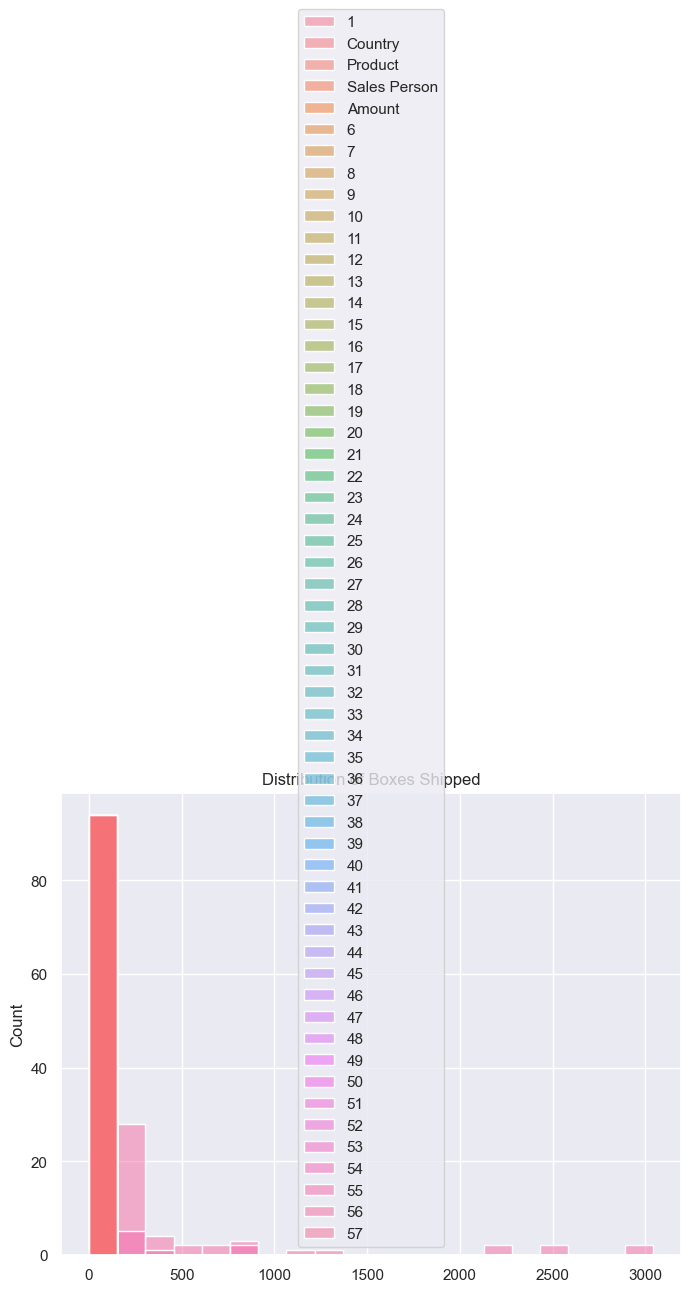

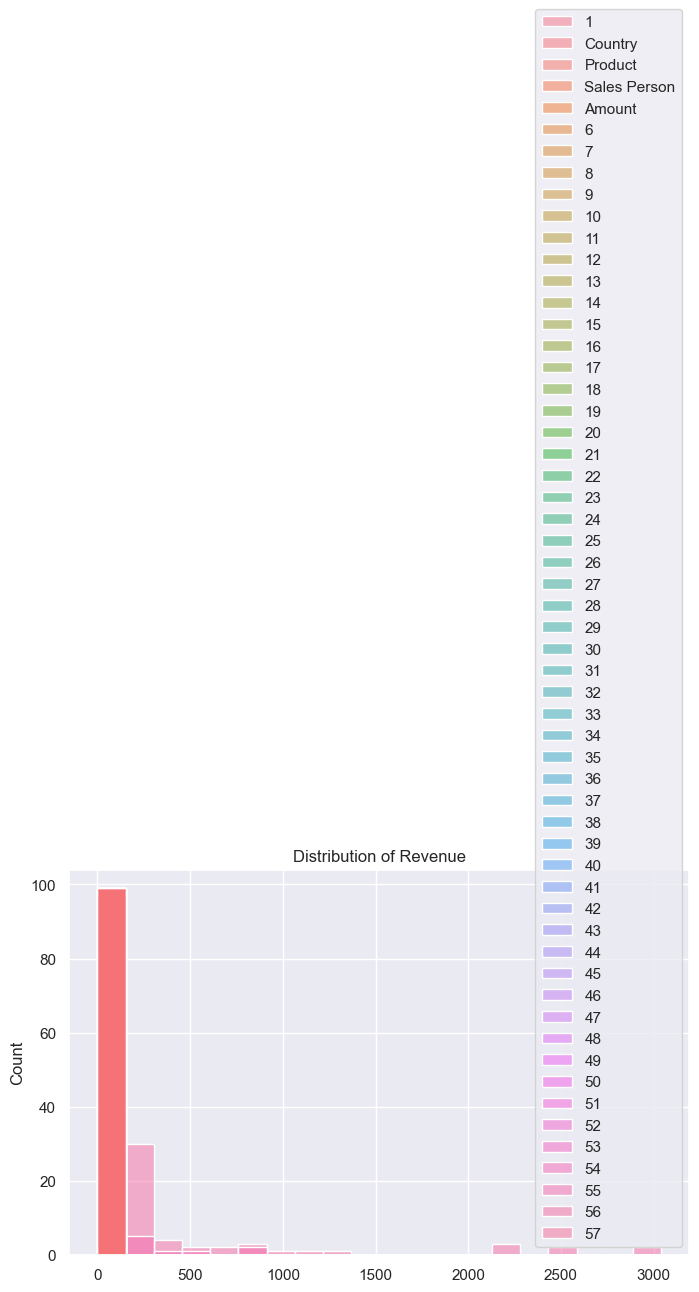

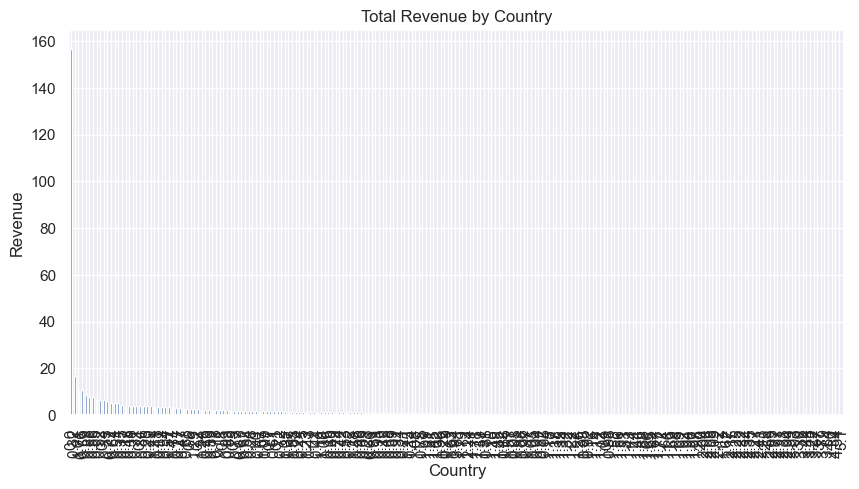

Country
0.00    156.82
0.32     16.67
1.01     10.61
0.76     10.58
0.59      8.77
         ...  
3.84      0.00
4.00      0.00
4.34      0.00
4.54      0.00
5.10      0.00
Name: Amount, Length: 214, dtype: float64


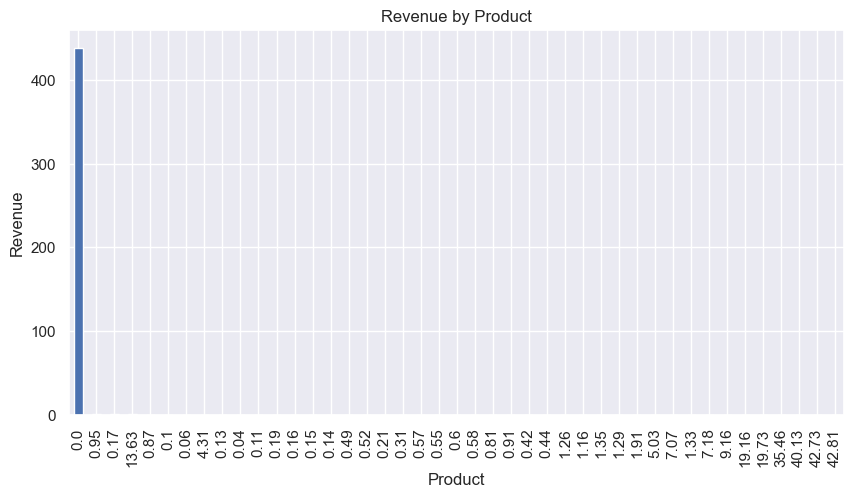

Product
0.00     437.73
0.95       0.95
0.17       0.68
13.63      0.67
0.87       0.43
0.10       0.42
0.06       0.17
4.31       0.16
0.13       0.03
0.04       0.00
0.11       0.00
0.19       0.00
0.16       0.00
0.15       0.00
0.14       0.00
0.49       0.00
0.52       0.00
0.21       0.00
0.31       0.00
0.57       0.00
0.55       0.00
0.60       0.00
0.58       0.00
0.81       0.00
0.91       0.00
0.42       0.00
0.44       0.00
1.26       0.00
1.16       0.00
1.35       0.00
1.29       0.00
1.91       0.00
5.03       0.00
7.07       0.00
1.33       0.00
7.18       0.00
9.16       0.00
19.16      0.00
19.73      0.00
35.46      0.00
40.13      0.00
42.73      0.00
42.81      0.00
Name: Amount, dtype: float64
Sales Person
0.00    190.24
0.80     11.61
0.85     11.26
0.44      8.80
0.64      7.05
0.65      6.82
0.30      5.04
0.25      4.82
1.05      4.62
0.87      4.39
Name: Amount, dtype: float64


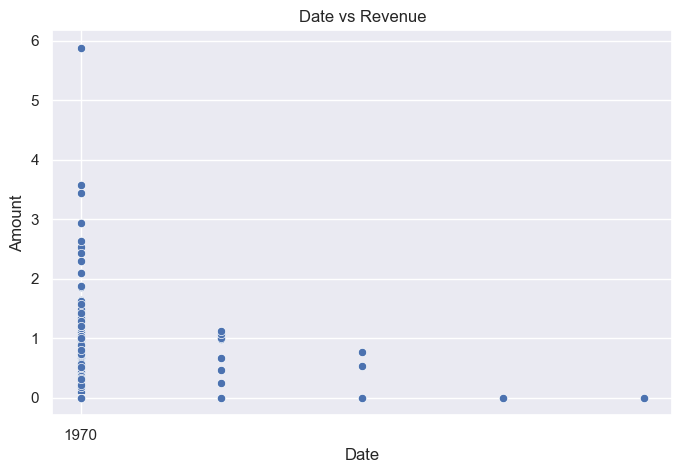

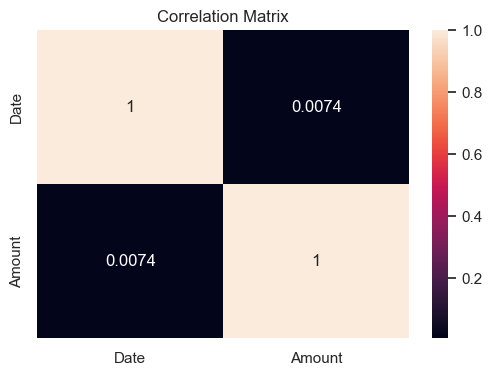

c:\Users\hp\miniconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


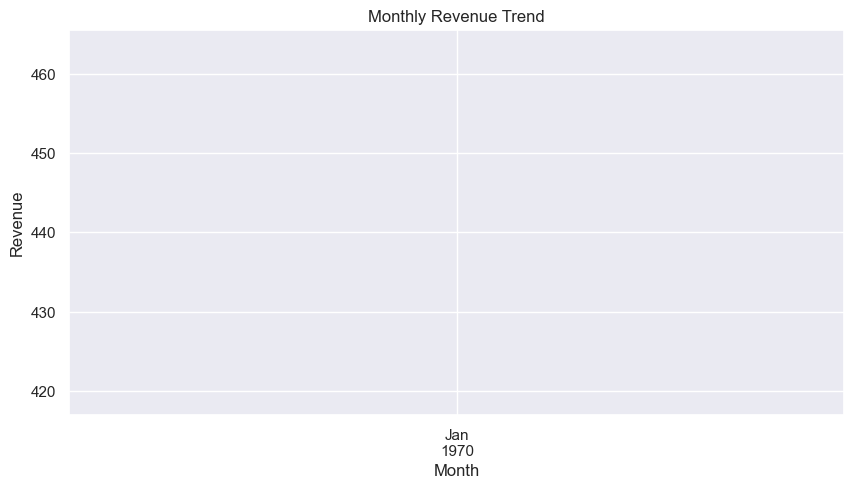

In [1]:
#lab 3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv("spambase/spambase.data", header=None)
sns.set()
print(df.head())
print(df.isna())
print(df.isna().sum())
df.duplicated()[df.duplicated()==True]
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])

print("number of columns: ", df.shape[1])

print(df.dtypes)


print ("")
print("after the changes \n")
df = df.rename(columns={0: 'Date', 5: 'Amount', 2:'Country',3:'Product',4:'Sales Person'})

df['Date'] = pd.to_datetime(df['Date']) 
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

print(df.dtypes)

print(df.describe(include='all'))
plt.figure(figsize=(8,6))
sns.histplot(df[6:100 ], bins=20) 
plt.title("Distribution of Boxes Shipped")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df[1:100], bins=20)
plt.title("Distribution of Revenue")
plt.show()

country_revenue = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue")
plt.show()

print(country_revenue)

product_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

print(product_revenue)

salesperson_revenue = (
    df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
)

print(salesperson_revenue.head(10))

plt.figure(figsize=(8,5))
sns.scatterplot(x='Date', y='Amount', data=df)
plt.title("Date vs Revenue")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[['Date', 'Amount']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()